# Stage 3: Modelling and Interaction Recovery

This stage fits the three interpretable models (Logistic Regression, a Generalised Additive Model, and an Explainable Boosting Machine) under identical conditions, then measures how well each one recovers the true borrower by macro interaction structure. Recovery is judged against a sealed planted oracle and against an economically emergent oracle, using one common ruler (Friedman's H squared for strength and a coefficient equivalent b hat for sign and size). Detection is judged against each model's own null calibrated threshold.

The heavy cells are checkpointed: with `REGENERATE = False` they reload the saved result files and the notebook opens in a few seconds, set `REGENERATE = True` to rerun the real experiment from scratch. It needs only `credit_dgp.py` and `pipeline_utils.py`.

### 3.0 Setup

Load the frozen preprocessing recipe and the sealed oracle from the earlier stages, mark which candidate pairs are genuinely active, and fix the experiment scale. `REGENERATE` is the single switch that decides whether the heavy cells recompute or reuse saved results.

In [ ]:
import os, sys, json, time, warnings, gc
import numpy as np, pandas as pd
# Make sure the project folder (where the simulator and helper modules live) is importable
sys.path.insert(0, os.getcwd())
# expit converts a log odds value into a probability, needed whenever we score a model.
from scipy.special import expit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, brier_score_loss, average_precision_score,
    precision_recall_curve)
from pygam import LogisticGAM, s, l, te
from interpret.glassbox import ExplainableBoostingClassifier
# Silence fit time warnings so the notebook output stays readable.
warnings.filterwarnings('ignore')
# The simulator (data generating process) and the shared helper library used across all stages.
import credit_dgp as dgp
from pipeline_utils import (apply_preprocessing, make_logreg_fn, make_gam_fn, make_ebm_fn,
    make_planted_experiment_oracle_fn, make_emergent_truth_fn, single_feature_pds,
    friedman_h2_and_bilinear, pure_interaction_surface, time_blocked_loan_disjoint_split,
    load_json, save_json, expected_calibration_error)

# Folder holding every saved result file for the project.
OUT = 'outputs'

# The one switch that controls the whole notebook. False reuses saved results and opens in seconds.
# True reruns the full experiment, which takes on the order of 2 hours because it fits the models
REGENERATE = False
# Timer for the run-config manifest saved later in this stage (meaningful when REGENERATE
# is True; near zero when everything below is reloaded from cache).
t_start = time.time()
# Audit trail for the GAM tensor-interaction basis. fit_models appends one record per GAM fit noting
# whether the intended tensor basis fitted or the routine fell back to a purely additive GAM. This is
# saved with the run config so the exact specification of every GAM fit is recorded, not left implicit
# (a reproducibility gap flagged in the critical evaluation).
GAM_FALLBACK_LOG = []

def cached(path):
    # A saved file is usable only when it already exists and we are not forcing a rerun.
    return (not REGENERATE) and os.path.exists(path)

def log(*a):
    # Timestamped progress print for the long running cells.
    print(f"[{time.strftime('%H:%M:%S')}]", *a, flush=True)

# The preprocessing recipe saved by Stage 2: frozen z scoring moments, the model input columns, and
# the 35 candidate interaction pairs. Every model and every oracle is built on exactly these features.
meta = load_json(f'{OUT}/preprocessing_meta.json')
# The public ground truth parameters (main effects and reference moments). This file deliberately does
# not contain the hidden interaction set, so loading it does not break the blind discovery design.
gt = load_json('ground_truth_params.json')
# The sealed private oracle: the five hidden active pairs with their signs and amplitudes. Stage 1 sealed
# this so the modelling could stay blind, and this is the reveal step where recovery is finally scored.
priv = load_json(f'{OUT}/oracle_planted_private.json')
hidden = priv['hidden_active_set']
# The full 35 pair candidate grid (names only) that the models are allowed to consider.
reg = meta['candidate_pairs']
# The model input columns, and the names of the 35 interaction product columns.
BASE = meta['base_features']; IX = [p['col'] for p in reg]
# A lookup from a feature name to its column position, used when building GAM terms and EBM pairs.
col_ix = {c: i for i, c in enumerate(BASE)}
# Flag which of the 35 candidate pairs are genuinely active, so recovery can be scored against truth.
active_set = {(h['micro'], h['macro']) for h in hidden}
for p in reg: p['is_active'] = (p['micro'], p['macro']) in active_set
# The distinct micro and macro axes, used as the background features for the interaction ruler.
feats = sorted({p['micro'] for p in reg} | {p['macro'] for p in reg})

# Experiment scale. These constants are the exact values behind every reported number.
SEEDS = [1, 2, 3, 4, 5]                     # five independent simulation replications
STRENGTHS = ['null', 'weak', 'moderate', 'strong']  # interaction off, weak, medium, and strong
# Amplitude for each named strength on the standardised bilinear product. Passing the amplitude (a float)
# to make_interaction_config keeps the simulator itself untouched; only this notebook defines the ladder.
STRENGTH_AMP = {'null': 0.0, 'weak': 0.10, 'moderate': 0.20, 'strong': 0.35}
N_ORIG = 600                                # loans originated per quarter in each simulated panel
N_NULL = 10                                 # interaction free panels used to calibrate detection
DEV_SUB = 90000                             # rows sampled to fit each model, keeps fitting tractable
TUNE_SUB = 30000                            # smaller sample used only for the hyperparameter search
N_BG = 130                                  # background rows the interaction ruler averages over
PAIRED = 777                                # common random number key so paired panels share borrowers
FLOOR_FRAC = 0.01                           # stabiliser for the H squared ratio under the null
print('Stage 3 setup ready. REGENERATE =', REGENERATE)

Stage 3 setup ready. REGENERATE = False


### 3.1 Model specifications and the common ruler

All three models are given the same fair chance: they see the same features and the same 35 candidate pairs. Logistic Regression enters the pairs as explicit product terms; the GAM expresses each pair as a smooth tensor surface; the EBM is restricted to exactly the same 35 pairs. The functions below build the GAM formula, turn a raw panel into the model ready matrix, and define the log loss used for tuning.

In [26]:
# build_terms assembles the GAM formula. A GAM is a sum of smooth functions, so every term is listed here.
def build_terms(nsp):
    # Start with no terms and add them one at a time.
    t = None
    # A smooth spline for each continuous micro and macro driver, so the main effects are free to bend.
    for c in meta['micro_z_smooth'] + meta['macro_z_smooth']:
        tt = s(col_ix[c], n_splines=5); t = tt if t is None else t + tt
    # A plain linear term for every remaining input, since dummy flags and counts need no spline.
    for c in BASE:
        if c not in meta['micro_z_smooth'] and c not in meta['macro_z_smooth']: t = t + l(col_ix[c])
    # A tensor product term for each candidate pair. The tensor is what lets the GAM express a genuine
    # two way interaction surface rather than just two separate main effects.
    for p in reg:
        # The self employed flag takes only two values, so it uses a reduced two knot linear basis on
        # that axis (a cubic spline is not valid on a variable with only two distinct values).
        if p['micro'] == 'emp_self_employed':
            tt = te(col_ix[p['micro']], col_ix[p['macro']], n_splines=[2, nsp], spline_order=[1, 3])
        # Every other pair uses a full spline tensor on both axes.
        else:
            tt = te(col_ix[p['micro']], col_ix[p['macro']], n_splines=[nsp, nsp])
        t = t + tt
    return t

# A tiny wrapper so the fitted logistic coefficients can be handed to the shared prediction helper in
# the shape it expects.
class _P:
    def __init__(self, pr): self.params = pr

# prep turns a raw simulated panel into the model ready feature matrix with a train and test label.
def prep(pan):
    # Keep only rows that have an observed next quarter outcome.
    mdl = pan[pan['default_next_quarter'].notna()].copy()
    # Make the target a clean integer, 0 for no default and 1 for default.
    mdl['default_next_quarter'] = mdl['default_next_quarter'].astype(int)
    # Apply the frozen Stage 2 preprocessing (z scoring, dummies, and the interaction products).
    X = apply_preprocessing(mdl, meta)
    # Label each row development, validation or confirmation using the loan disjoint and time blocked
    # split, then drop rows that fall outside their block so no loan appears in two partitions.
    X['part'] = time_blocked_loan_disjoint_split(X, meta['split']['dev_end'], meta['split']['val_end'])
    return X[X['part'].notna()].copy()

# Log loss scores how well calibrated a set of predicted probabilities is. Lower is better, and it is
# the criterion used to pick hyperparameters.
def _logloss(y, p):
    # Clip away from 0 and 1 so the logarithm stays finite.
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return float(-np.mean(y * np.log(p) + (1 - y) * np.log(1 - p)))

### 3.2 Fitting, tuning and the interaction ruler

`tune` picks the hyperparameters once on the validation split (you never tune to maximise interaction recovery, only to maximise held out fit, which keeps the recovery result honest). `fit_models` then fits all three with the chosen settings. `rulers` applies the identical H squared and b hat measurement to every model, which is what makes the cross model comparison fair.

In [27]:
# TUNED will hold the winning hyperparameters after the search below has run.
TUNED = None

def tune(dev, val):
    global TUNED
    # Run the search on a smaller sample for speed. The chosen settings transfer to the full fit.
    d = dev if len(dev) <= TUNE_SUB else dev.sample(TUNE_SUB, random_state=7)
    y = d['default_next_quarter'].values; Xb = d[BASE].astype(float).values
    # Validation targets and design matrices used to score each candidate setting.
    yv = val['default_next_quarter'].values
    Xv_lr = val[BASE + IX].astype(float).values; Xv_g = val[BASE].astype(float).values
    # Keep the whole search so it can be reported.
    tbl = {'LR': [], 'GAM': [], 'EBM': []}
    # Search the logistic ridge strength C over a small grid.
    bestLR = None
    for C_ in [0.3, 1.0, 3.0]:
        m = LogisticRegression(penalty='l2', C=C_, max_iter=3000, solver='lbfgs').fit(d[BASE + IX].astype(float).values, y)
        ll = _logloss(yv, m.predict_proba(Xv_lr)[:, 1]); tbl['LR'].append({'C': C_, 'valLL': ll})
        if bestLR is None or ll < bestLR[1]: bestLR = (C_, ll)
    # Search the GAM smoothing strength lam. A single spline count keeps the search small and the fit fast.
    bestG = None
    for lam in [0.2, 0.6, 2.0]:
        for nsp in [5]:
            try:
                g = LogisticGAM(build_terms(nsp), max_iter=100, lam=lam).fit(Xb, y)
                ll = _logloss(yv, g.predict_proba(Xv_g))
            except Exception as e:
                ll = float('inf'); log('   GAM setting failed', lam, nsp, e)
            tbl['GAM'].append({'lam': lam, 'n_splines': nsp, 'valLL': ll})
            if bestG is None or ll < bestG[2]: bestG = (lam, nsp, ll)
    # Search the EBM learning rate.
    bestE = None
    pair_idx = [(col_ix[p['micro']], col_ix[p['macro']]) for p in reg]
    for lr in [0.01, 0.02]:
        e = ExplainableBoostingClassifier(interactions=pair_idx, outer_bags=2, max_rounds=2000,
                                          learning_rate=lr, random_state=42, n_jobs=1).fit(Xb, y)
        ll = _logloss(yv, e.predict_proba(Xv_g)[:, 1]); tbl['EBM'].append({'learning_rate': lr, 'valLL': ll})
        if bestE is None or ll < bestE[1]: bestE = (lr, ll)
    # Store the winning settings alongside the full search table.
    TUNED = {'LR': {'C': bestLR[0]}, 'GAM': {'lam': bestG[0], 'n_splines': bestG[1]},
             'EBM': {'learning_rate': bestE[0]}, 'grid': tbl, 'dev_sub': DEV_SUB}
    return TUNED

def fit_models(dev, tag=None):
    # Sample the development rows to a fixed size so every model sees the same amount of data.
    d = dev if len(dev) <= DEV_SUB else dev.sample(DEV_SUB, random_state=7)
    y = d['default_next_quarter'].values; Xb = d[BASE].astype(float).values
    # Logistic regression with the tuned ridge strength, fit on the base features plus the 35 explicit
    # interaction product columns.
    lr = LogisticRegression(penalty='l2', C=TUNED['LR']['C'], max_iter=3000, solver='lbfgs').fit(
        d[BASE + IX].astype(float).values, y)
    lr_params = pd.Series({'const': float(lr.intercept_[0]), **dict(zip(BASE + IX, lr.coef_[0]))})
    # GAM with the tuned smoothing strength. If building the tensor terms ever fails, fall back to a
    # purely linear additive GAM so the cell still completes rather than crashing. Either way the outcome
    # is RECORDED in GAM_FALLBACK_LOG (with the caller's tag), so the exact specification of every GAM
    # fit is auditable rather than silent.
    gam_fell_back = False
    try:
        gam = LogisticGAM(build_terms(TUNED['GAM']['n_splines']), max_iter=100, lam=TUNED['GAM']['lam']).fit(Xb, y)
    except Exception as _e:
        gam_fell_back = True
        log(f'   GAM tensor basis FELL BACK to additive-only (tag={tag}):', _e)
        lin = None
        for i in range(len(BASE)): lin = l(i) if lin is None else lin + l(i)
        gam = LogisticGAM(lin, max_iter=100, lam=1.0).fit(Xb, y)
    GAM_FALLBACK_LOG.append({'tag': tag, 'fell_back': bool(gam_fell_back),
                             'basis': 'additive_only' if gam_fell_back else 'tensor_interactions'})
    # EBM restricted to exactly the 35 declared pairs, so it searches the same grid as the others rather
    # than a free pairwise search.
    pair_idx = [(col_ix[p['micro']], col_ix[p['macro']]) for p in reg]
    ebm = ExplainableBoostingClassifier(interactions=pair_idx, outer_bags=2, max_rounds=2000,
                                        learning_rate=TUNED['EBM']['learning_rate'],
                                        random_state=42, n_jobs=1).fit(Xb, y)
    # Wrap each fitted model in a function that returns log odds, so the ruler can treat them all alike.
    return {'Logistic': make_logreg_fn(_P(lr_params), meta), 'GAM': make_gam_fn(gam, meta),
            'EBM': make_ebm_fn(ebm, meta)}

def rulers(FNS, Xbg):
    # H2 holds the interaction strength per pair, BH holds the coefficient equivalent b hat per pair.
    H2 = {m: {} for m in FNS}; BH = {m: {} for m in FNS}
    for m, f in FNS.items():
        # The spread of this model's predictions, used to stop the H squared ratio blowing up when a
        # pair barely moves the prediction.
        base_pred = np.asarray(f(Xbg)); pv = float(np.var(base_pred - base_pred.mean()))
        # Each feature's solo partial dependence, the baseline that the interaction is measured against.
        pd1 = single_feature_pds(f, Xbg, feats)
        # For every candidate pair, measure how much of the joint effect is a genuine interaction.
        for p in reg:
            h, b = friedman_h2_and_bilinear(f, Xbg, p['micro'], p['macro'], pd1,
                                            pred_var=pv, floor_frac=FLOOR_FRAC)
            H2[m][p['col']] = float(h); BH[m][p['col']] = float(b)
    return H2, BH

### 3.3 Hyperparameter tuning

Tune once on the seed 1 moderate panel and freeze the result. Selecting by validation log loss (not by how much interaction the model recovers) is what keeps the later recovery numbers a fair test.

In [28]:
# Path to the saved hyperparameters.
TUNING_PATH = f'{OUT}/model_tuning.json'
if cached(TUNING_PATH):
    # Reuse the settings already chosen so the notebook opens quickly.
    TUNED = load_json(TUNING_PATH)
    print('loaded tuned hyperparameters:', {k: TUNED[k] for k in ['LR', 'GAM', 'EBM']})
else:
    # Generate the seed 1 moderate panel, split it, and run the search on it.
    log('generating seed 1 moderate panel for tuning ...')
    cfg_m = dgp.make_interaction_config(hidden, 'moderate')
    pan0 = dgp.generate_panel(seed=1, n_orig_per_quarter=N_ORIG, interaction_config=cfg_m,
                              use_vasicek=False, paired_seed=PAIRED)
    X0 = prep(pan0); dev0 = X0[X0['part'] == 'dev']; val0 = X0[X0['part'] == 'val']
    tune(dev0, val0); save_json(TUNED, TUNING_PATH)
    print('tuned hyperparameters:', {k: TUNED[k] for k in ['LR', 'GAM', 'EBM']})
    del pan0, X0; gc.collect()

loaded tuned hyperparameters: {'LR': {'C': 0.3}, 'GAM': {'lam': 2.0, 'n_splines': 5}, 'EBM': {'learning_rate': 0.01}}


### 3.4 Null calibration

Fit the models on ten panels where the interaction is switched off, and record the largest spurious H squared each model produces. The 90th percentile of those spurious maxima becomes each model's own detection threshold, so a detection claim is judged against that model's own noise floor.

In [29]:
NULL_PATH = f'{OUT}/null_thresholds.json'
if cached(NULL_PATH):
    # Reuse the saved thresholds.
    nt = load_json(NULL_PATH); thr = nt['threshold_90pct']
    print('loaded null thresholds:', {m: round(v, 4) for m, v in thr.items()})
else:
    log('null calibration across', N_NULL, 'interaction free panels ...')
    null_max = {m: [] for m in ['Logistic', 'GAM', 'EBM']}
    for k in range(N_NULL):
        # A panel with the interaction switched off, so any H squared the models show is spurious.
        pan = dgp.generate_panel(seed=2000 + k, n_orig_per_quarter=N_ORIG,
                                 interaction_config=dgp.make_interaction_config(hidden, 'null'),
                                 use_vasicek=False, paired_seed=PAIRED)
        X = prep(pan); dev = X[X['part'] == 'dev']; conf = X[X['part'] == 'conf']
        # Fit the models and measure interactions on a background sample from the confirmation block.
        FNS = fit_models(dev, tag=f'null_panel_{k}')
        Xbg = conf.sample(min(N_BG, len(conf)), random_state=100).reset_index(drop=True)
        H2, _ = rulers(FNS, Xbg)
        # Record the single largest spurious H squared each model produces on this panel.
        for m in null_max: null_max[m].append(max(H2[m].values()))
        log(f'  null {k+1}/{N_NULL}')
        del pan, X; gc.collect()
    # The detection threshold is the 90th percentile of those spurious maxima.
    thr = {m: float(np.quantile(null_max[m], 0.90)) for m in null_max}
    save_json({'null_max_H2': null_max, 'threshold_90pct': thr, 'floor_frac': FLOOR_FRAC}, NULL_PATH)
    print('null thresholds:', {m: round(v, 4) for m, v in thr.items()})

loaded null thresholds: {'Logistic': 1.1116, 'GAM': 0.9115, 'EBM': 0.0526}


### 3.5 Planted interaction recovery

The main experiment. For every seed and strength, simulate the panel, fit the three models, and measure each model's interaction against the exact oracle for that condition, on a shared background sample. Both the per pair recovery records and the confirmation set predictive scores are saved.

In [30]:
RECOV_PATH = f'{OUT}/recovery.json'
if cached(RECOV_PATH):
    recov = load_json(RECOV_PATH); print('loaded recovery records:', len(recov['records']))
else:
    log('planted recovery across', len(SEEDS), 'seeds x', len(STRENGTHS), 'strengths ...')
    recs = []; pred = []
    for seed in SEEDS:
        for strength in STRENGTHS:
            # Build this condition's interaction configuration and simulate the panel.
            cfg = dgp.make_interaction_config(hidden, STRENGTH_AMP[strength])
            pan = dgp.generate_panel(seed=seed, n_orig_per_quarter=N_ORIG, interaction_config=cfg,
                                     use_vasicek=False, paired_seed=PAIRED)
            X = prep(pan); dev = X[X['part'] == 'dev']; conf = X[X['part'] == 'conf']
            # Fit the three models on development data.
            FNS = fit_models(dev, tag=f'recovery_seed{seed}_{strength}')
            # The exact oracle for this condition, which is the correct recovery target.
            f_oracle = make_planted_experiment_oracle_fn(gt, meta, cfg)
            # A shared background sample so all models and the oracle are measured identically.
            Xbg = conf.sample(min(N_BG, len(conf)), random_state=100).reset_index(drop=True)
            H2, BH = rulers({**FNS, 'Oracle': f_oracle}, Xbg)
            # Predictive quality on the held out confirmation set. Alongside AUC/Brier/ECE we also record
            # the calibration slope (logistic regression of the outcome on the predicted log-odds; 1.0 is
            # perfectly calibrated in the large, <1 means over-confident spread) and average precision
            # (area under the precision-recall curve, the minority default-class view), both requested in
            # the critical evaluation as stronger companions to AUC.
            yc = conf['default_next_quarter'].values
            for m, f in FNS.items():
                lpc = np.asarray(f(conf)); pc = expit(lpc)
                if 1 < int(yc.sum()) < len(yc):
                    cs = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000).fit(lpc.reshape(-1, 1), yc)
                    cal_slope = float(cs.coef_[0, 0])
                else:
                    cal_slope = float('nan')
                pred.append({'seed': seed, 'strength': strength, 'model': m,
                             'auc': float(roc_auc_score(yc, pc)), 'brier': float(brier_score_loss(yc, pc)),
                             'ece': float(expected_calibration_error(yc, pc)),
                             'cal_slope': cal_slope, 'avg_precision': float(average_precision_score(yc, pc))})
            # One recovery record per model per candidate pair, including whether it clears the threshold.
            for m in ['Logistic', 'GAM', 'EBM']:
                for p in reg:
                    recs.append({'seed': seed, 'strength': strength, 'model': m, 'pair': p['col'],
                                 'is_active': bool(p['is_active']), 'H2': H2[m][p['col']], 'bhat': BH[m][p['col']],
                                 'oracle_bhat': BH['Oracle'][p['col']], 'detected': bool(H2[m][p['col']] > thr[m])})
            log(f"  seed {seed} {strength} done (rate {conf['default_next_quarter'].mean():.3%})")
            del pan, X; gc.collect()
    save_json({'records': recs, 'predictive': pred}, RECOV_PATH)
    recov = {'records': recs, 'predictive': pred}

loaded recovery records: 2100


### 3.6 Structural emergent fidelity

The second truth. Here no product term is planted: the macro economy flows into the affordability accounting and the hazard is convex, so the interaction emerges from economic mechanics. We check whether each model's whole b hat pattern across the 35 surfaces matches this emergent oracle.

In [31]:
STRUCT_PATH = f'{OUT}/structural_fidelity.json'
if cached(STRUCT_PATH):
    strec = load_json(STRUCT_PATH); print('loaded structural fidelity rows:', len(strec))
else:
    log('structural emergent fidelity across', len(SEEDS), 'seeds ...')
    strec = []
    # The economically emergent truth: no planted product, the interaction arises from the accounting.
    f_em = make_emergent_truth_fn(gt, meta)
    for seed in SEEDS:
        # Simulate an emergent mode panel and fit the models on it.
        pan = dgp.generate_panel(seed=seed, n_orig_per_quarter=N_ORIG, mode='emergent',
                                 use_vasicek=False, paired_seed=PAIRED)
        X = prep(pan); dev = X[X['part'] == 'dev']; conf = X[X['part'] == 'conf']
        FNS = fit_models(dev, tag=f'structural_seed{seed}')
        Xbg = conf.sample(min(N_BG, len(conf)), random_state=100).reset_index(drop=True)
        H2, BH = rulers({**FNS, 'Oracle': f_em}, Xbg)
        for m in ['Logistic', 'GAM', 'EBM']:
            # Compare the model's b hat pattern across all 35 surfaces to the emergent oracle's pattern.
            mb = np.array([BH[m][p['col']] for p in reg]); ob = np.array([BH['Oracle'][p['col']] for p in reg])
            # Restrict the sign agreement check to surfaces where the oracle interaction is clearly non zero.
            strong = np.abs(ob) >= 0.05
            sign_agree = float(np.mean(np.sign(mb[strong]) == np.sign(ob[strong]))) if strong.any() else float('nan')
            # A single correlation between the model and oracle b hat fingerprints across all pairs.
            corr = float(np.corrcoef(mb, ob)[0, 1]) if len(mb) > 2 else float('nan')
            strec.append({'seed': seed, 'model': m, 'sign_agree_strong': sign_agree,
                          'surface_corr': corr, 'rmse': float(np.sqrt(np.mean((mb - ob) ** 2)))})
        log(f'  structural seed {seed} done')
        del pan, X; gc.collect()
    save_json(strec, STRUCT_PATH)

loaded structural fidelity rows: 15


Save a small run configuration manifest, straight from this notebook's own constants and tuned settings. Stage 5 reads this file for its reproducibility manifest.

In [32]:
# Record the exact configuration and tuned settings behind every number in this stage.
CONFIG_PATH = f'{OUT}/run_config.json'
# GAM basis audit: how many GAM fits used the intended tensor-interaction basis versus fell back to a
# purely additive specification. When REGENERATE is False no fits happened this session, so the log is
# empty and the previously saved audit (if any) is left untouched.
gam_fallbacks = [r for r in GAM_FALLBACK_LOG if r['fell_back']]
gam_audit = {'n_gam_fits': len(GAM_FALLBACK_LOG), 'n_fell_back': len(gam_fallbacks),
             'all_tensor_basis': len(GAM_FALLBACK_LOG) > 0 and len(gam_fallbacks) == 0,
             'fallback_tags': [r['tag'] for r in gam_fallbacks], 'detail': GAM_FALLBACK_LOG}
if GAM_FALLBACK_LOG:
    save_json(gam_audit, f'{OUT}/gam_fallback_stage3.json')
    print(f"GAM basis audit: {gam_audit['n_gam_fits']} fits, {gam_audit['n_fell_back']} fell back to additive-only.")
else:
    print('GAM basis audit: no fits this session (REGENERATE=False); existing audit left untouched.')
save_json({'pilot': False, 'full': True, 'seeds': SEEDS, 'strengths': STRENGTHS, 'n_orig': N_ORIG,
           'n_null': N_NULL, 'dev_sub': DEV_SUB, 'n_bg': N_BG, 'floor_frac': FLOOR_FRAC,
           'tuned': {k: TUNED[k] for k in ['LR', 'GAM', 'EBM']},
           'gam_basis_audit': gam_audit,
           'elapsed_min': round((time.time() - t_start) / 60, 1)}, CONFIG_PATH)
print('run config manifest saved:', CONFIG_PATH)

GAM basis audit: no fits this session (REGENERATE=False); existing audit left untouched.
run config manifest saved: outputs/run_config.json


### 3.7 Results

The cells below read the saved results and present them. Predictive quality first, then interaction recovery (magnitude scored against the oracle's own ruler measured b hat, which is the honest target because the ruler attenuates every function it measures), then the detection thresholds and the structural fidelity.

In [33]:
# Predictive league: average AUC, Brier, calibration error, calibration slope and average precision
# across every seed and strength. cal_slope near 1.0 is well calibrated in the large; avg_precision is
# the area under the precision-recall curve, the minority default-class companion to AUC.
P = pd.DataFrame(load_json(f'{OUT}/recovery.json')['predictive'])
_cols = [c for c in ['auc', 'brier', 'ece', 'cal_slope', 'avg_precision'] if c in P.columns]
league = P.groupby('model')[_cols].mean().round(4).sort_values('auc', ascending=False)
print('AUC is the chance the model ranks a real defaulter above a non defaulter; Brier and ECE are error, lower is better.')
print('cal_slope: 1.0 = calibrated in the large (<1 over-confident); avg_precision: PR-curve area for the rare default class.')
display(league)

AUC is the chance the model ranks a real defaulter above a non defaulter; Brier and ECE are error, lower is better.
cal_slope: 1.0 = calibrated in the large (<1 over-confident); avg_precision: PR-curve area for the rare default class.


,auc,brier,ece,cal_slope,avg_precision
model,,,,,
EBM,0.7857,0.0081,0.0013,0.9712,0.0600
Logistic,0.7622,0.0098,0.0067,0.5368,0.0373
GAM,0.7491,0.0104,0.0079,0.4662,0.0344


In [34]:
# The league table above averages away seed and strength; this checks whether the AUC ordering is
# consistent, not just a coincidence of averaging. The five seeds recur across all four strength
# conditions, so the twenty (seed, strength) results per model are matched, correlated pairs, not
# independent draws, which is exactly what the Wilcoxon signed-rank test is built for. Uses only the
# already-loaded predictive records, no new fitting or simulation.
from scipy.stats import wilcoxon
piv = P.pivot_table(index=['seed', 'strength'], columns='model', values='auc')
print(f'Paired Wilcoxon signed-rank on AUC across {len(piv)} matched (seed, strength) conditions:')
rows = []
for a, b in [('EBM', 'Logistic'), ('EBM', 'GAM'), ('Logistic', 'GAM')]:
    stat, p = wilcoxon(piv[a], piv[b])
    rows.append({'comparison': f'{a} vs {b}', 'statistic': round(stat, 1), 'p_value': p})
display(pd.DataFrame(rows).set_index('comparison'))

Paired Wilcoxon signed-rank on AUC across 20 matched (seed, strength) conditions:


,statistic,p_value
comparison,,
EBM vs Logistic,8.0,0.000048
EBM vs GAM,1.0,0.000004
Logistic vs GAM,6.0,0.000027


In [35]:
# Interaction recovery table. Two magnitude views are reported side by side because they answer
# different questions and can disagree (a point made in the critical evaluation):
#   recovery_%_vs_oracle  = signed MEAN coefficient scaling, mean(b_hat)/mean(oracle_b_hat). This is an
#                           AVERAGE-scale measure, so over- and under-shoot on different pairs can cancel.
#   norm_abs_err_%        = normalised per-pair MEAN ABSOLUTE error, mean|b_hat - oracle_b_hat| divided by
#                           mean|oracle_b_hat| over the active pairs. This does NOT let errors cancel, so
#                           it is the honest pair-by-pair accuracy. Lower is better.
R = pd.DataFrame(load_json(f'{OUT}/recovery.json')['records'])
rows = []
for (m, st), g in R[R.strength.isin(['weak', 'moderate', 'strong'])].groupby(['model', 'strength']):
    # Active pairs are the genuinely planted ones; decoy pairs had nothing planted.
    a = g[g.is_active]; d = g[~g.is_active]
    # Average magnitude on active and decoy pairs, and the oracle's own measured magnitude.
    mb = a['bhat'].abs().mean(); ob = a['oracle_bhat'].abs().mean(); dc = d['bhat'].abs().mean()
    # Signed recovery penalises a sign flipped pair rather than crediting it as positive magnitude.
    signed = a['bhat'].mean() / a['oracle_bhat'].mean()
    # Normalised per-pair absolute error (no cancellation), as a percentage of the oracle scale.
    norm_abs_err = 100 * (a['bhat'] - a['oracle_bhat']).abs().mean() / ob if ob > 0 else float('nan')
    rows.append({'model': m, 'strength': st, 'b_active': round(mb, 3), 'oracle_b': round(ob, 3),
        'recovery_%_vs_oracle': round(100 * signed, 1), 'norm_abs_err_%': round(norm_abs_err, 1),
        'b_decoy': round(dc, 3), 'active/decoy': round(mb / dc, 2),
        'sign_acc': round((np.sign(a['bhat']) == np.sign(a['oracle_bhat'])).mean(), 2),
        'power': round(a['detected'].mean(), 2), 'decoy_fpr': round(d['detected'].mean(), 3)})
display(pd.DataFrame(rows).set_index(['model', 'strength']).sort_index())

b_active  oracle_b  recovery_%_vs_oracle  norm_abs_err_%  \
model    strength                                                             
EBM      moderate     0.028     0.142                  18.2            81.8   
         strong       0.059     0.252                  23.2            76.8   
         weak         0.007     0.072                   7.7            92.3   
GAM      moderate     0.171     0.142                 107.6            70.1   
         strong       0.274     0.252                 104.0            50.5   
         weak         0.120     0.072                  98.9           145.3   
Logistic moderate     0.147     0.142                  98.9            49.7   
         strong       0.235     0.252                  93.3            33.4   
         weak         0.109     0.072                  86.9           113.0   

                   b_decoy  active/decoy  sign_acc  power  decoy_fpr  
model    strength                                                     
EBM      moderate    0.008          3.51      0.92   0.00      0.027  
         strong      0.012          5.06      0.92   0.32      0.087  
         weak        0.004          1.98      0.80   0.00      0.007  
GAM      moderate    0.086          1.98      0.88   0.00      0.007  
         strong      0.118          2.32      0.96   0.12      0.020  
         weak        0.100          1.19      0.72   0.04      0.013  
Logistic moderate    0.070          2.10      0.92   0.00      0.007  
         strong      0.089          2.64      1.00   0.00      0.000  
         weak        0.077          1.41      0.76   0.00      0.007

In [36]:
# Null calibrated detection thresholds and how spread out the spurious H squared was across the 10 panels.
nt = load_json(f'{OUT}/null_thresholds.json')
nm = pd.DataFrame(nt['null_max_H2'])
display(pd.DataFrame({'threshold_90pct': pd.Series(nt['threshold_90pct']).round(4),
    'null_mean': nm.mean().round(3), 'null_sd': nm.std().round(3), 'null_max': nm.max().round(3)}))

,threshold_90pct,null_mean,null_sd,null_max
Logistic,1.1116,0.955,0.326,1.805
GAM,0.9115,0.708,0.242,1.293
EBM,0.0526,0.025,0.027,0.079


In [37]:
# Structural emergent fidelity: how well each model matches the unplanted economic interaction pattern.
sf = pd.DataFrame(load_json(f'{OUT}/structural_fidelity.json'))
display(sf.groupby('model')[['sign_agree_strong', 'surface_corr', 'rmse']].mean().round(3).sort_values('surface_corr', ascending=False))

,sign_agree_strong,surface_corr,rmse
model,,,
EBM,1.000,0.422,0.038
Logistic,0.933,0.380,0.152
GAM,0.933,0.317,0.171


In [38]:
# Is each model's mean structural-fidelity correlation genuinely above zero, or could it be noise from
# a small number of seeds? One-sample t-test against zero correlation across the five seeds, using only
# the already-loaded structural fidelity records, no new fitting or simulation.
from scipy.stats import ttest_1samp
print('One-sample t-test (H0: mean surface correlation = 0), across 5 seeds:')
for m, grp in sf.groupby('model'):
    t, p = ttest_1samp(grp['surface_corr'], 0)
    print(f'  {m:9s} mean={grp["surface_corr"].mean():.3f}  t={t:.2f}  p={p:.4g}')

One-sample t-test (H0: mean surface correlation = 0), across 5 seeds:
  EBM       mean=0.422  t=5.39  p=0.005713
  GAM       mean=0.317  t=5.70  p=0.004675
  Logistic  mean=0.380  t=8.61  p=0.001001


### 3.8 Figures

The figures are drawn inline from the results, not loaded as pre made images. The heavy part (fitting a representative model set and computing the interaction surfaces) is checkpointed the same way as the rest of the stage: it runs when `REGENERATE` is True or when the saved plot data is missing, and otherwise the small saved plot data is reused. The plotting cells below then render live every time the notebook runs.

In [39]:
# Compute the plot data that the model based figures need: the interaction surfaces, the calibration,
# the ROC and the precision-recall points. This fits one representative model set (the strong strength
# seed 1 condition) so the surfaces show the true structure clearly. It is saved to two small files so
# the plots below can render instantly on later runs without refitting.
import matplotlib.pyplot as plt
from pipeline_utils import pure_interaction_surface
from sklearn.metrics import roc_curve
os.makedirs('figures', exist_ok=True)
SURF_PATH = 'figures/surface_data.json'; CALIB_PATH = 'figures/calib_roc_data.json'
# Colours used consistently for the three models across every figure.
CLR = {'Logistic': '#2a6fdb', 'GAM': '#d98a1e', 'EBM': '#1a9e74', 'Oracle': '#333333'}
if REGENERATE or not (os.path.exists(SURF_PATH) and os.path.exists(CALIB_PATH)):
    # Simulate and fit the strong seed 1 condition, plus its exact oracle, for the figures.
    log('fitting the strong seed 1 model set for the figures ...')
    cfgS = dgp.make_interaction_config(hidden, 'strong')
    panS = dgp.generate_panel(seed=1, n_orig_per_quarter=N_ORIG, interaction_config=cfgS, use_vasicek=False, paired_seed=PAIRED)
    XS = prep(panS); devS = XS[XS['part'] == 'dev']; confS = XS[XS['part'] == 'conf']
    FNS_fig = fit_models(devS, tag='figure_strong_seed1'); f_oracle = make_planted_experiment_oracle_fn(gt, meta, cfgS)
    # Surfaces are shown on the two macro axes that are well behaved in the confirmation data (Bank Rate
    # and Wage) plus one decoy pair. GDP and CPI have fat tails in this period that would distort the
    # surface, so those pairs are reported through the recovery table instead of a surface plot.
    PAIRS_FIG = [('z_dti', 'z_rate', 'DTI x Bank Rate  (active)'),
                 ('z_income', 'z_wage', 'Income x Wage  (active)'),
                 ('z_util', 'z_rate', 'Utilisation x Bank Rate  (decoy)')]
    # Use the SAME background sampling as the main recovery ruler (N_BG rows, random_state=100), so the
    # b-hat annotated on each panel is measured on the identical background the recovery table uses for
    # this seed-1/strong condition. (Earlier this figure drew a smaller, differently-seeded background,
    # which produced marginally different EBM annotations; matching the sampling removes that mismatch.)
    Xbg = confS.sample(min(N_BG, len(confS)), random_state=100).reset_index(drop=True)
    grid = np.linspace(-2, 2, 21)
    funcs = [('Oracle', f_oracle)] + [(m, FNS_fig[m]) for m in ['Logistic', 'GAM', 'EBM']]

    # The same H2/b-hat ruler used everywhere else in this stage, applied to just the one pair being
    # plotted, measured on the same background as the recovery table for this condition.
    def _bhat_here(f, cj, ck):
        base_pred = np.asarray(f(Xbg)); pv = float(np.var(base_pred - base_pred.mean()))
        pd1 = single_feature_pds(f, Xbg, [cj, ck])
        _, b = friedman_h2_and_bilinear(f, Xbg, cj, ck, pd1, pred_var=pv, floor_frac=FLOOR_FRAC)
        return float(b)

    # For each pair, compute the pure interaction surface and the measured b-hat for the oracle and
    # each model, plus the raw axis column names so the render cell can label the axes properly.
    pairs_out = []
    for cj, ck, title in PAIRS_FIG:
        surfs = {name: pure_interaction_surface(f, Xbg, cj, ck, grid, grid).tolist() for name, f in funcs}
        bhats = {name: _bhat_here(f, cj, ck) for name, f in funcs}
        pairs_out.append({'title': title, 'cj': cj, 'ck': ck, 'is_active': 'decoy' not in title.lower(),
                          'surfaces': surfs, 'bhat': bhats})
    save_json({'grid': grid.tolist(), 'pairs': pairs_out}, SURF_PATH)
    # Calibration (predicted versus realised default rate by decile), ROC, and precision-recall points on
    # the confirmation set. The PR curve is the minority default-class view requested in the evaluation.
    yc = confS['default_next_quarter'].values; calib = {}; roc = {}; prc = {}
    for m, f in FNS_fig.items():
        p = expit(np.asarray(f(confS)))
        dfc = pd.DataFrame({'p': p, 'y': yc}); dfc['b'] = pd.qcut(dfc['p'], 10, duplicates='drop')
        cal = dfc.groupby('b', observed=True).agg(pm=('p', 'mean'), yr=('y', 'mean'))
        calib[m] = {'pm': (cal['pm'] * 100).tolist(), 'yr': (cal['yr'] * 100).tolist()}
        # Downsample the ROC curve to 200 points so the saved file stays small.
        fpr, tpr, _ = roc_curve(yc, p); idx = np.linspace(0, len(fpr) - 1, 200).astype(int)
        roc[m] = {'fpr': fpr[idx].tolist(), 'tpr': tpr[idx].tolist(), 'auc': float(roc_auc_score(yc, p))}
        # Precision-recall curve, likewise downsampled, with the average precision (PR-area) summary.
        prec, rec, _ = precision_recall_curve(yc, p); jdx = np.linspace(0, len(prec) - 1, 200).astype(int)
        prc[m] = {'precision': np.asarray(prec)[jdx].tolist(), 'recall': np.asarray(rec)[jdx].tolist(),
                  'ap': float(average_precision_score(yc, p)), 'base_rate': float(yc.mean())}
    save_json({'calibration': calib, 'roc': roc, 'pr': prc}, CALIB_PATH)
    del panS, XS; gc.collect(); log('figure plot data saved.')
else:
    print('plot data already present; the figures below will render from it.')

plot data already present; the figures below will render from it.


**Figure 3.1: recovered interaction surfaces.** Logistic and GAM reproduce the true structure, EBM captures the direction but attenuates the magnitude, and the decoy pair is flat for every model.

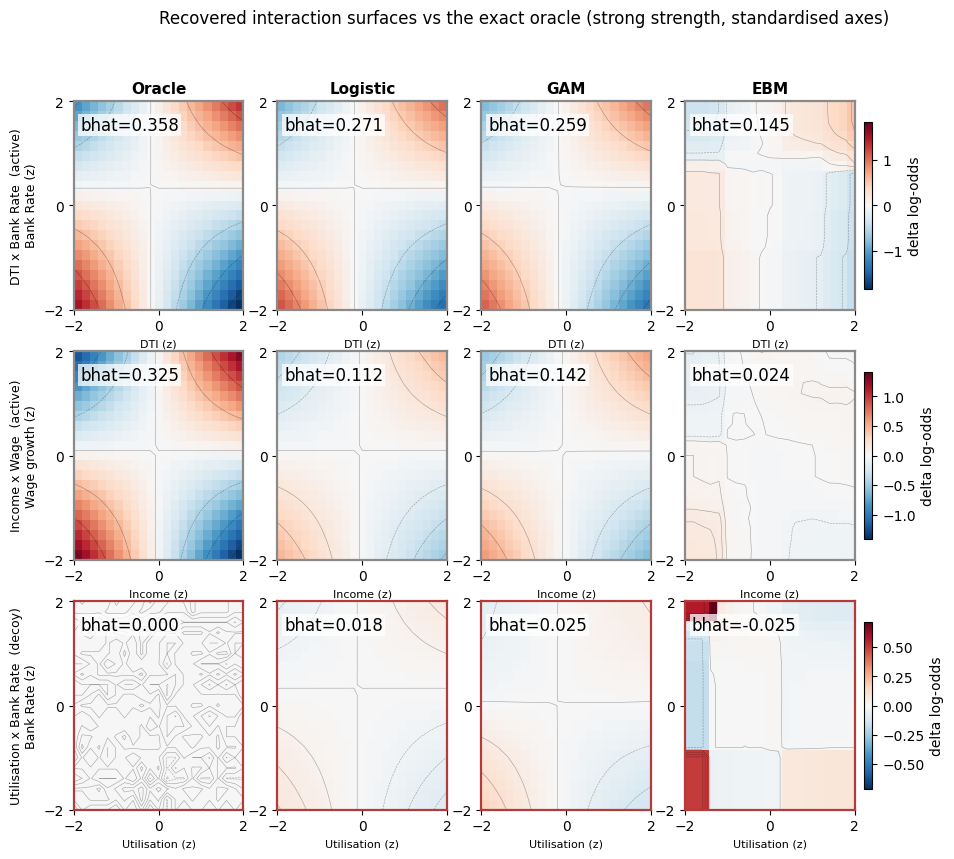

In [50]:
# Draw the surface grid live from the saved plot data. Each panel is annotated with its measured
# b-hat so the colour intensity (magnitude) can be read as an exact number, not just judged visually.
AXIS_NAME = {'z_dti': 'DTI', 'z_rate': 'Bank Rate', 'z_income': 'Income', 'z_wage': 'Wage growth',
             'z_util': 'Utilisation'}
sd = load_json('figures/surface_data.json'); grid = np.array(sd['grid'])
names = ['Oracle', 'Logistic', 'GAM', 'EBM']
fig, axes = plt.subplots(len(sd['pairs']), len(names), figsize=(12, 9.2))
for i, pr in enumerate(sd['pairs']):
    # Load the four surfaces for this pair and use one shared symmetric colour scale so oracle and
    # models are directly comparable to each other (scoped to this row only, see the caption).
    surfs = {n: np.array(pr['surfaces'][n]) for n in names}
    vmax = max(1e-4, max(np.abs(s).max() for s in surfs.values()))
    xname = AXIS_NAME.get(pr['cj'], pr['cj']); yname = AXIS_NAME.get(pr['ck'], pr['ck'])
    # A red border marks the decoy row: nothing was planted here, so a flat surface in every panel,
    # including the oracle, is the correct, expected result rather than a modelling failure.
    border = '#b23b3b' if not pr['is_active'] else '#8a8a8a'
    for j, n in enumerate(names):
        ax = axes[i, j]
        im = ax.imshow(surfs[n].T, origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                       extent=[grid[0], grid[-1], grid[0], grid[-1]], aspect='auto')
        # Faint contour lines make the saddle shape of a genuine interaction easier to read than
        # colour alone, especially once the figure is shrunk onto a printed page.
        ax.contour(grid, grid, surfs[n].T, colors='k', linewidths=0.4, alpha=0.35, levels=6)
        # The measured b-hat behind this panel's colour, so magnitude can be read exactly.
        ax.text(0.04, 0.93, f"bhat={pr['bhat'][n]:.3f}", transform=ax.transAxes, fontsize=12,
               va='top', ha='left', bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1.5))
        for sp in ax.spines.values(): sp.set_edgecolor(border); sp.set_linewidth(1.6)
        if i == 0: ax.set_title(n, fontweight='bold', fontsize=11)
        if j == 0: ax.set_ylabel(f"{pr['title']}\n{yname} (z)", fontsize=9)
        ax.set_xlabel(f'{xname} (z)', fontsize=8)
        ax.set_xticks([-2, 0, 2]); ax.set_yticks([-2, 0, 2]); ax.grid(False)
    fig.colorbar(im, ax=list(axes[i, :]), shrink=0.8, pad=0.01, label='delta log-odds')
fig.suptitle('Recovered interaction surfaces vs the exact oracle (strong strength, standardised axes)')
plt.show()

**Figure 3.1b: interaction slices (fixed-macro line view).** A complementary read of Figure 3.1, plotting the same fitted functions as line profiles instead of a heatmap: the effect of the micro variable at a low (dashed) and a high (solid) macro condition. This is the classic way an interaction effect is shown in applied statistics, an Aiken and West style interaction plot (Aiken & West, 1991): parallel lines mean no interaction, and the more the two lines fan apart, the stronger it is. The vertical gap between the lines at any micro value is a direct, precise read of the interaction magnitude, easier to judge exactly than colour intensity by eye. The same red border flags the decoy row and the same b-hat annotation from Figure 3.1 is reused, so both views report the identical number.

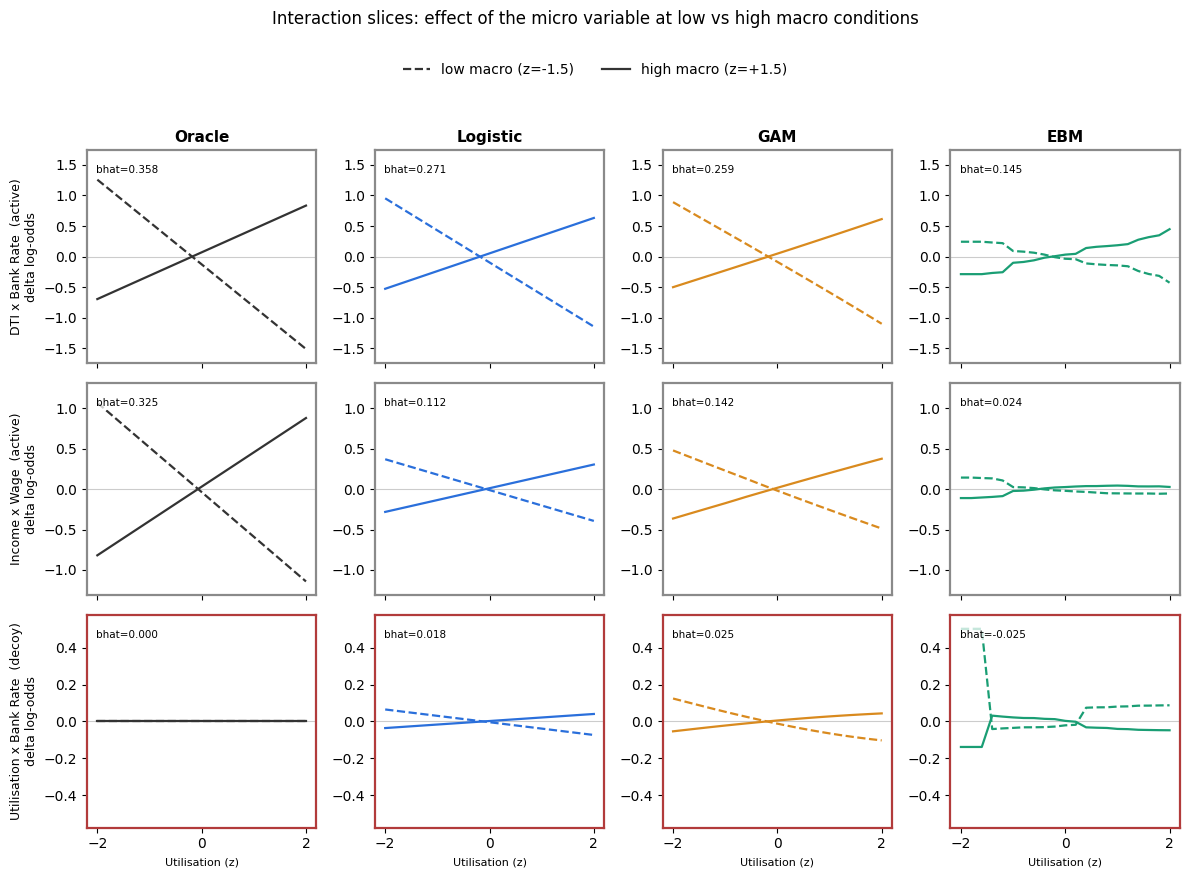

In [41]:
# Draw a complementary view of the same surfaces: fixed-macro slices instead of a full heatmap. No new
# fitting is needed, this reuses the exact same surface data Figure 3.1 already computed and saved.
from matplotlib.lines import Line2D
sd = load_json('figures/surface_data.json'); grid = np.array(sd['grid'])
# Two fixed macro conditions: -1.5 SD ("low") and +1.5 SD ("high"), the standard Aiken & West choice.
lo_idx = int(np.argmin(np.abs(grid + 1.5))); hi_idx = int(np.argmin(np.abs(grid - 1.5)))
names = ['Oracle', 'Logistic', 'GAM', 'EBM']
fig, axes = plt.subplots(len(sd['pairs']), len(names), figsize=(12, 8.0), sharex=True)
for i, pr in enumerate(sd['pairs']):
    xname = AXIS_NAME.get(pr['cj'], pr['cj']); yname = AXIS_NAME.get(pr['ck'], pr['ck'])
    border = '#b23b3b' if not pr['is_active'] else '#8a8a8a'
    # Shared y-limits within the row, the same convention as the heatmap's shared colour scale.
    ymax = max(1e-4, max(max(abs(np.array(pr['surfaces'][n])[:, lo_idx]).max(),
                             abs(np.array(pr['surfaces'][n])[:, hi_idx]).max()) for n in names))
    for j, n in enumerate(names):
        ax = axes[i, j]
        surf = np.array(pr['surfaces'][n])
        ax.axhline(0, color='#ccc', lw=0.8, zorder=0)
        # Dashed = low macro condition, solid = high macro condition, same colour per model as elsewhere.
        ax.plot(grid, surf[:, lo_idx], '--', color=CLR[n], lw=1.6)
        ax.plot(grid, surf[:, hi_idx], '-', color=CLR[n], lw=1.6)
        ax.set_ylim(-ymax * 1.15, ymax * 1.15)
        ax.text(0.04, 0.93, f"bhat={pr['bhat'][n]:.3f}", transform=ax.transAxes, fontsize=7.5,
               va='top', ha='left', bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1.5))
        for sp in ax.spines.values(): sp.set_edgecolor(border); sp.set_linewidth(1.6)
        if i == 0: ax.set_title(n, fontweight='bold', fontsize=11)
        if j == 0: ax.set_ylabel(f"{pr['title']}\ndelta log-odds", fontsize=9)
        if i == len(sd['pairs']) - 1: ax.set_xlabel(f'{xname} (z)', fontsize=8)
        ax.set_xticks([-2, 0, 2])
# One shared legend (dashed = low macro, solid = high macro) instead of repeating it in every panel.
handles = [Line2D([0], [0], color='#333333', ls='--', lw=1.6, label='low macro (z=-1.5)'),
           Line2D([0], [0], color='#333333', ls='-', lw=1.6, label='high macro (z=+1.5)')]
fig.legend(handles=handles, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.04), frameon=False)
fig.suptitle('Interaction slices: effect of the micro variable at low vs high macro conditions', y=1.09)
fig.tight_layout()
plt.show()

**Figure 3.2: active versus decoy interaction magnitude.** The number on each bar is the signal to noise separation (active magnitude divided by decoy magnitude).

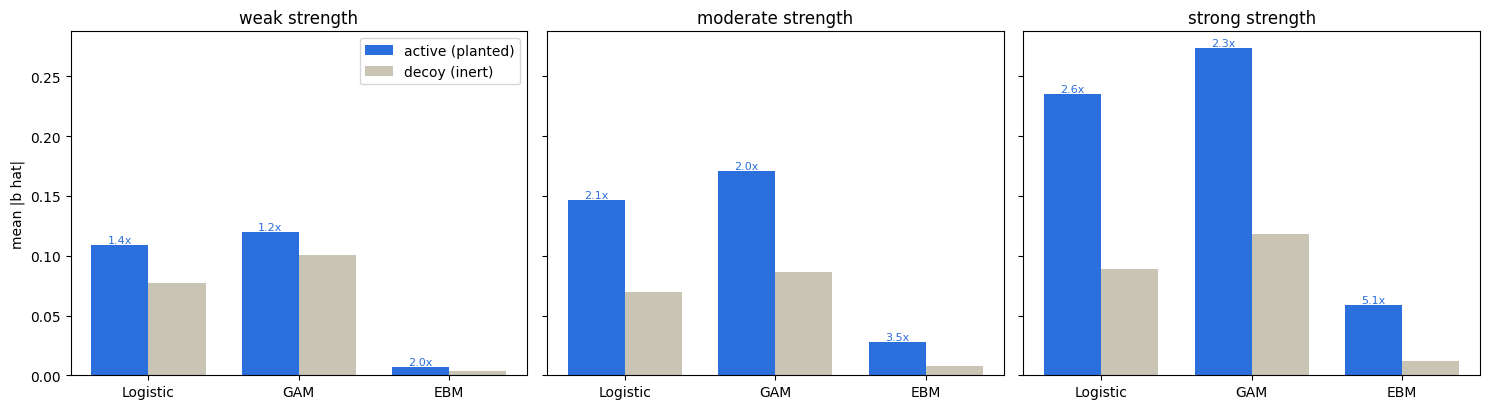

In [42]:
# Draw the active versus decoy magnitude bars live from the recovery records.
R = pd.DataFrame(load_json(f'{OUT}/recovery.json')['records'])
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for k, st in enumerate(['weak', 'moderate', 'strong']):
    g = R[R.strength == st]; models = ['Logistic', 'GAM', 'EBM']; x = np.arange(3); w = 0.38
    # Mean absolute interaction magnitude on active pairs and on decoy pairs.
    act = [g[(g.model == m) & g.is_active]['bhat'].abs().mean() for m in models]
    dec = [g[(g.model == m) & ~g.is_active]['bhat'].abs().mean() for m in models]
    ax[k].bar(x - w/2, act, w, color='#2a6fdb', label='active (planted)')
    ax[k].bar(x + w/2, dec, w, color='#c9c4b4', label='decoy (inert)')
    ax[k].set_xticks(x); ax[k].set_xticklabels(models); ax[k].set_title(f'{st} strength')
    for xi, (a, d) in enumerate(zip(act, dec)):
        ax[k].text(xi - w/2, a, f'{a/d:.1f}x', ha='center', va='bottom', fontsize=8, color='#2a6fdb')
ax[0].set_ylabel('mean |b hat|'); ax[0].legend(); fig.tight_layout(); plt.show()

**Figure 3.3: null calibration thresholds.** Spurious H squared across the ten interaction free panels, with each model's detection threshold marked. EBM's floor is much lower and tighter than the others.

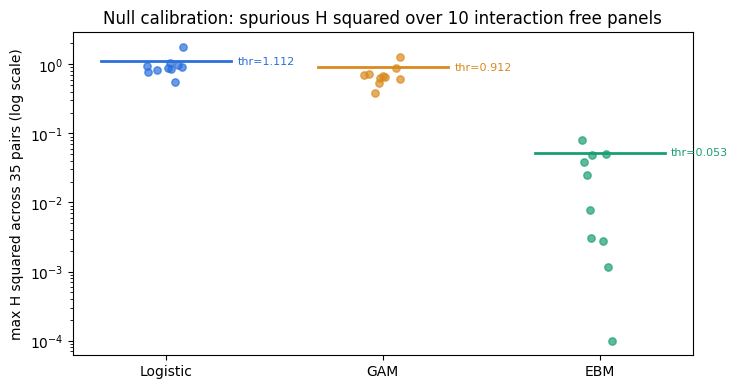

In [43]:
# Draw the null threshold strip live from the saved null calibration.
nt = load_json(f'{OUT}/null_thresholds.json')
fig, ax = plt.subplots(figsize=(8, 4.2))
for i, m in enumerate(['Logistic', 'GAM', 'EBM']):
    # A little horizontal jitter so the ten points per model are visible.
    v = np.array(nt['null_max_H2'][m]); jit = i + (np.random.default_rng(i).random(len(v)) - 0.5) * 0.18
    ax.scatter(jit, np.maximum(v, 1e-4), color=CLR[m], alpha=0.7, s=28, zorder=3)
    thr = nt['threshold_90pct'][m]; ax.plot([i - 0.3, i + 0.3], [thr, thr], color=CLR[m], lw=2)
    ax.text(i + 0.33, thr, f'thr={thr:.3f}', va='center', fontsize=8, color=CLR[m])
ax.set_yscale('log'); ax.set_xticks(range(3)); ax.set_xticklabels(['Logistic', 'GAM', 'EBM'])
ax.set_ylabel('max H squared across 35 pairs (log scale)')
ax.set_title('Null calibration: spurious H squared over 10 interaction free panels'); plt.show()

**Figure 3.4: calibration and ROC.** The left panel is the key one: it shows how close each model's predicted probability is to the realised default rate. The right panel shows discrimination.

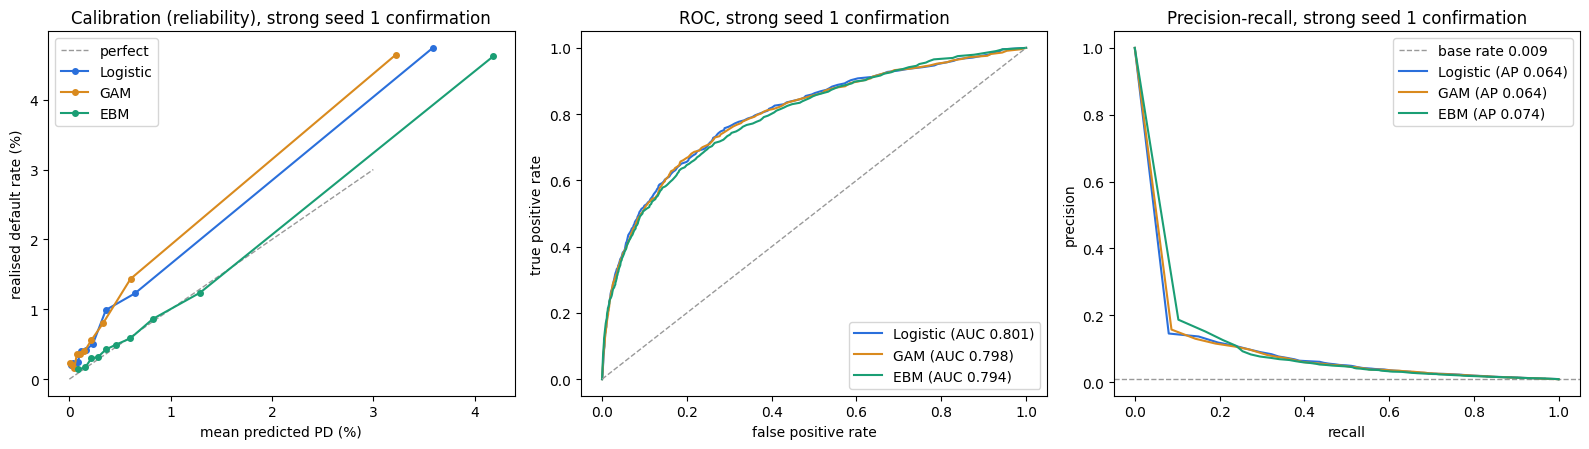

In [44]:
# Draw calibration, ROC and precision-recall live from the saved plot data.
cr = load_json('figures/calib_roc_data.json')
fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
# Left: reliability diagram. The dashed line is perfect calibration.
ax[0].plot([0, 3], [0, 3], '--', color='#999', lw=1, label='perfect')
for m in ['Logistic', 'GAM', 'EBM']:
    c = cr['calibration'][m]; ax[0].plot(c['pm'], c['yr'], 'o-', color=CLR[m], label=m, ms=4)
ax[0].set_xlabel('mean predicted PD (%)'); ax[0].set_ylabel('realised default rate (%)')
ax[0].set_title('Calibration (reliability), strong seed 1 confirmation'); ax[0].legend()
# Middle: ROC curves with the area under the curve.
for m in ['Logistic', 'GAM', 'EBM']:
    r = cr['roc'][m]; ax[1].plot(r['fpr'], r['tpr'], color=CLR[m], label=f"{m} (AUC {r['auc']:.3f})")
ax[1].plot([0, 1], [0, 1], '--', color='#999', lw=1)
ax[1].set_xlabel('false positive rate'); ax[1].set_ylabel('true positive rate')
ax[1].set_title('ROC, strong seed 1 confirmation'); ax[1].legend()
# Right: precision-recall curves, the minority default-class view. The dashed line is the no-skill
# baseline (the default base rate); average precision (AP) is the area under each PR curve.
if 'pr' in cr:
    base = cr['pr']['Logistic'].get('base_rate')
    if base is not None:
        ax[2].axhline(base, ls='--', color='#999', lw=1, label=f'base rate {base:.3f}')
    for m in ['Logistic', 'GAM', 'EBM']:
        pr = cr['pr'][m]; ax[2].plot(pr['recall'], pr['precision'], color=CLR[m], label=f"{m} (AP {pr['ap']:.3f})")
    ax[2].set_xlabel('recall'); ax[2].set_ylabel('precision')
    ax[2].set_title('Precision-recall, strong seed 1 confirmation'); ax[2].legend()
fig.tight_layout(); plt.show()

In [45]:
# Compute actual versus predicted default rate by calendar quarter, fitted once on the emergent
# structural world (the same world Stage 4 later freezes for stress testing), then scored on every
# development and validation row. Development quarters are an in-sample fit check; validation
# quarters are genuinely out-of-sample, so this shows whether each model tracks the true UK
# macro-driven default rate through real calendar time, not just in one aggregate calibration number.
TIME_PATH = 'figures/actual_pred_time.json'
if REGENERATE or not os.path.exists(TIME_PATH):
    log('fitting the emergent seed 1 model set for the actual vs predicted time figure ...')
    panT = dgp.generate_panel(seed=1, n_orig_per_quarter=N_ORIG, mode='emergent',
                              use_vasicek=False, paired_seed=PAIRED)
    XT = prep(panT)
    devT = XT[XT['part'] == 'dev']
    devvalT = XT[XT['part'].isin(['dev', 'val'])].copy()
    FNS_time = fit_models(devT)
    # Group rows by calendar quarter (not origination quarter), so the x axis is real historical time.
    devvalT['q'] = devvalT['observation_quarter'].astype('period[Q]').astype(str)
    rows = []
    for q, grp in devvalT.groupby('q', sort=True):
        rec = {'quarter': q, 'part': grp['part'].iloc[0],
               'actual': float(grp['default_next_quarter'].mean()) * 100}
        for m, f in FNS_time.items():
            rec[m] = float(np.mean(expit(np.asarray(f(grp))))) * 100
        rows.append(rec)
    rows.sort(key=lambda r: r['quarter'])
    save_json({'rows': rows, 'dev_end': meta['split']['dev_end']}, TIME_PATH)
    del panT, XT, devvalT; gc.collect(); log('actual vs predicted time data saved.')
else:
    print('actual vs predicted time data already present; the figure below will render from it.')

actual vs predicted time data already present; the figure below will render from it.


**Figure 3.5: actual versus predicted default rate over calendar time.** Each model is fit once on development rows from the emergent, structural world, then scored quarter by quarter across the whole development and validation window (2001 to 2019). The dashed line marks where validation begins: everything left of it is an in-sample fit check, everything right of it is a genuinely out-of-sample track record the models never saw while fitting.

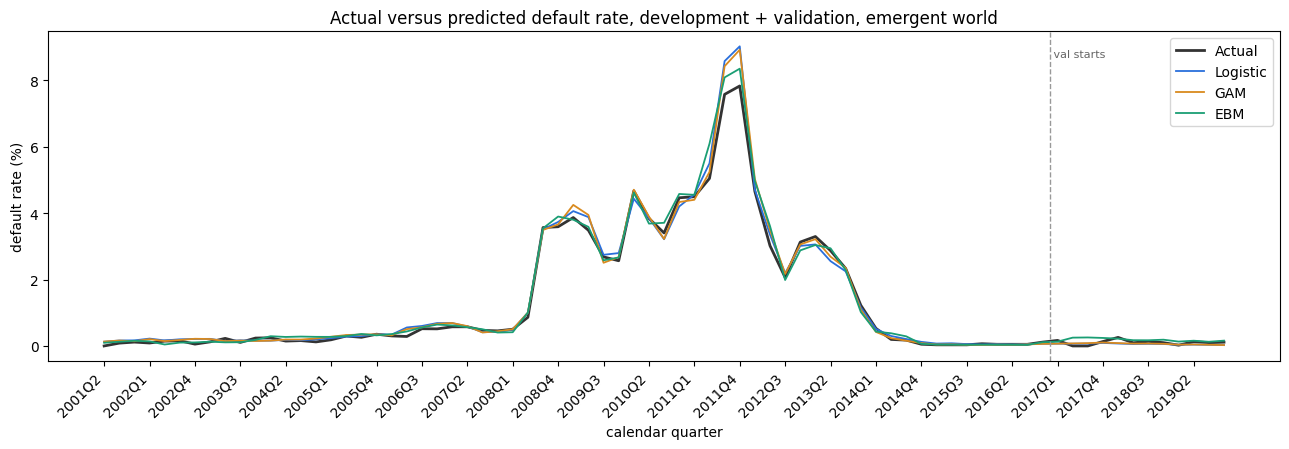

In [46]:
# Draw actual versus predicted default rate over calendar time, live from the saved plot data.
td = load_json('figures/actual_pred_time.json'); rows = pd.DataFrame(td['rows'])
fig, ax = plt.subplots(figsize=(13, 4.6))
ax.plot(rows['quarter'], rows['actual'], color='#333333', lw=2, label='Actual')
for m in ['Logistic', 'GAM', 'EBM']:
    ax.plot(rows['quarter'], rows[m], color=CLR[m], lw=1.3, label=m)
# Mark the development / validation boundary: everything to the left is an in-sample fit check,
# everything to the right is genuinely out-of-sample, never seen while fitting.
dev_end_ix = rows.index[rows['quarter'] == td['dev_end']]
if len(dev_end_ix):
    ax.axvline(dev_end_ix[0] + 0.5, color='#999', ls='--', lw=1)
    ax.text(dev_end_ix[0] + 0.5, ax.get_ylim()[1] * 0.92, ' val starts', fontsize=8, color='#666')
# Thin out the x tick labels so a near twenty year quarterly axis stays readable.
step = max(1, len(rows) // 20)
ax.set_xticks(range(0, len(rows), step)); ax.set_xticklabels(rows['quarter'][::step], rotation=45, ha='right')
ax.set_xlabel('calendar quarter'); ax.set_ylabel('default rate (%)')
ax.set_title('Actual versus predicted default rate, development + validation, emergent world')
ax.legend(); fig.tight_layout(); plt.show()

**Figure 3.6: magnitude recovery versus formal detection power (strong condition).** The same two numbers already reported in the recovery table above (section 3.7), plotted against each other so the trade-off is visible directly: Logistic and GAM sit far right (accurate magnitude) but low (weak detection), EBM sits further left (attenuated magnitude) but highest on detection. No model is in the top-right corner.

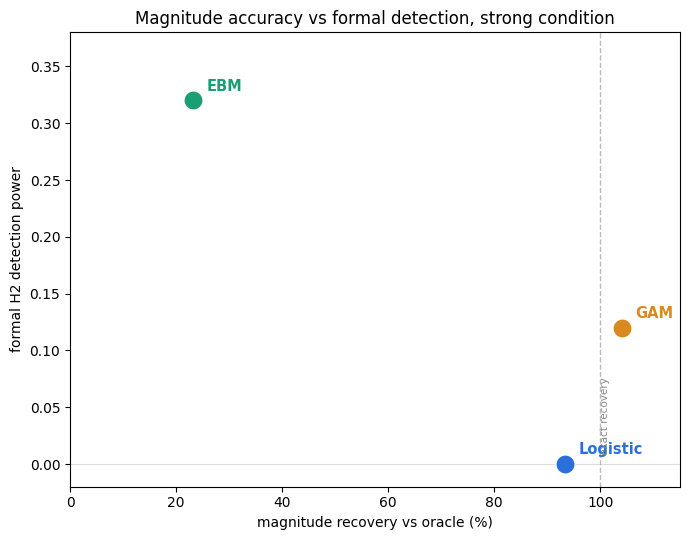

In [47]:
# Draw the recovery-versus-detection tension directly: magnitude recovery (%) against formal H2
# detection power, both already computed and saved in recovery.json. No new fitting or simulation
# here, this only re-plots the same strong-condition numbers already shown in the results table
# above (section 3.7), using the identical formulas, so the two views cannot disagree.
R = pd.DataFrame(load_json(f'{OUT}/recovery.json')['records'])
g = R[R.strength == 'strong']
pts = []
for m in ['Logistic', 'GAM', 'EBM']:
    a = g[(g.model == m) & g.is_active]
    recov_pct = 100 * a['bhat'].mean() / a['oracle_bhat'].mean()
    power = a['detected'].mean()
    pts.append((m, recov_pct, power))

fig, ax = plt.subplots(figsize=(7, 5.5))
for m, x, y in pts:
    ax.scatter(x, y, s=200, color=CLR[m], zorder=3, edgecolor='white', linewidth=1.3)
    ax.annotate(m, (x, y), textcoords='offset points', xytext=(10, 7), fontsize=10.5,
                fontweight='bold', color=CLR[m])
ax.axhline(0, color='#ddd', lw=0.8, zorder=0)
ax.axvline(100, color='#bbb', lw=1, ls='--', zorder=0)
ax.text(100, 0.005, ' exact recovery', fontsize=7.5, color='#888', rotation=90, va='bottom')
ax.set_xlim(0, 115); ax.set_ylim(-0.02, 0.38)
ax.set_xlabel('magnitude recovery vs oracle (%)')
ax.set_ylabel('formal H2 detection power')
ax.set_title('Magnitude accuracy vs formal detection, strong condition')
fig.tight_layout()
plt.show()

**Figure 3.7: structural (emergent) interaction surfaces and pointwise shape error.** The recovery figures above use the *planted* oracle. This figure instead shows the *emergent* oracle, the interaction that arises purely from the affordability accounting with no product term planted, for the three pairs where the emergent interaction is strongest. Each model surface is compared to the oracle surface not only by its single b-hat number but by a direct pointwise error (NRMSE, the root-mean-square difference across the whole surface grid, normalised by the oracle surface scale). This is a stronger test of shape recovery than the coefficient-fingerprint correlation reported in Section 3.6: a model can match the oracle's average slope while still getting the shape of the surface wrong.

structural surface data already present; the figure below will render from it.


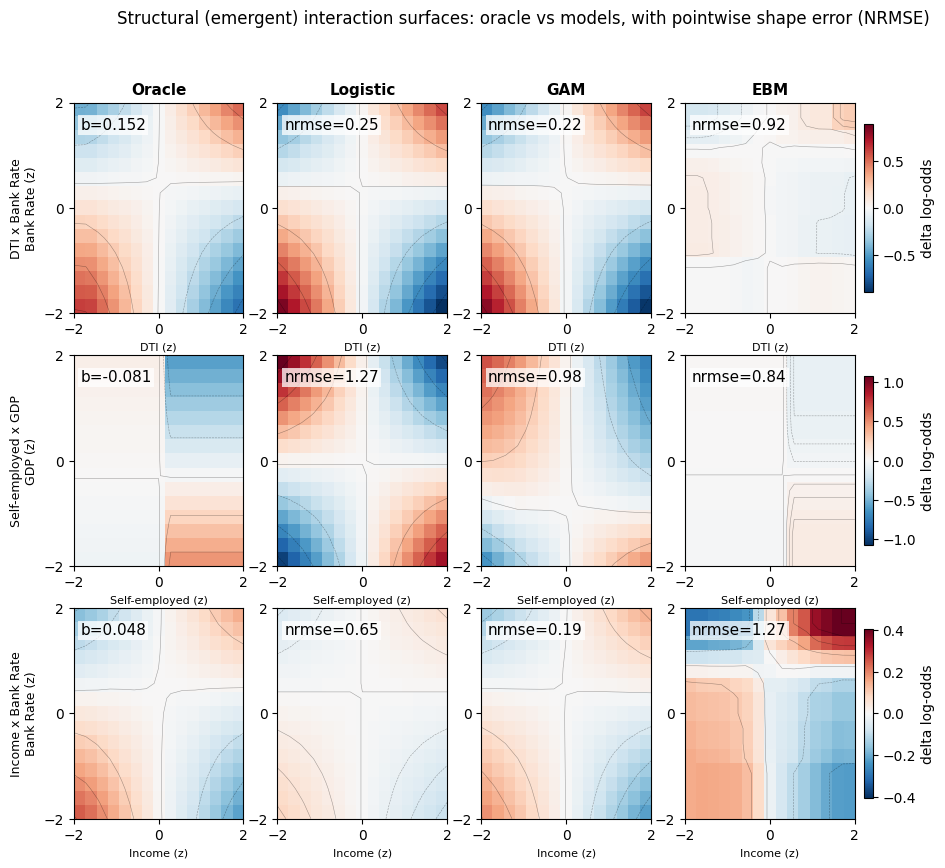

In [53]:
# Structural (emergent) interaction surfaces + a direct POINTWISE surface error. Sections 3.1 and the
# recovery table above compare each model to the PLANTED oracle; the structural fidelity table (3.6)
# scores the EMERGENT oracle but only through a single b-hat fingerprint number per pair. Here we render
# the emergent interaction SURFACES themselves (oracle vs each model) for the pairs where the emergent
# interaction is strongest, and compute the pointwise RMSE between each model surface and the oracle
# surface, a stronger measure of SHAPE recovery than the coefficient-fingerprint correlation alone (both
# gaps flagged in the critical evaluation). Checkpointed like the other figure cells; fits the emergent
# seed-1 model set once, on the same background sampling (N_BG, random_state=100) as the recovery ruler.
STRUCT_SURF_PATH = 'figures/structural_surface_data.json'; STRUCT_PW_PATH = f'{OUT}/structural_pointwise.json'
_AX = {'z_income': 'Income', 'z_dti': 'DTI', 'z_util': 'Utilisation', 'z_pti': 'PTI',
       'z_savbuf': 'Savings buffer', 'z_lti': 'LTI', 'emp_self_employed': 'Self-employed',
       'z_unemp': 'Unemployment', 'z_cpi': 'CPI', 'z_rate': 'Bank Rate', 'z_gdp': 'GDP', 'z_wage': 'Wage growth'}
if REGENERATE or not (os.path.exists(STRUCT_SURF_PATH) and os.path.exists(STRUCT_PW_PATH)):
    log('fitting emergent seed 1 for structural surfaces + pointwise error ...')
    panE = dgp.generate_panel(seed=1, n_orig_per_quarter=N_ORIG, mode='emergent', use_vasicek=False, paired_seed=PAIRED)
    XE = prep(panE); devE = XE[XE['part'] == 'dev']; confE = XE[XE['part'] == 'conf']
    FNS_e = fit_models(devE, tag='structural_surface_seed1'); f_em = make_emergent_truth_fn(gt, meta)
    Xbg = confE.sample(min(N_BG, len(confE)), random_state=100).reset_index(drop=True)
    # Rank the candidate pairs by the emergent oracle's own interaction magnitude on this background, and
    # take the three strongest, the pairs where a shape comparison is actually meaningful.
    op = np.asarray(f_em(Xbg)); opv = float(np.var(op - op.mean()))
    pd1o = single_feature_pds(f_em, Xbg, feats)
    ob = {}
    for p in reg:
        _, b = friedman_h2_and_bilinear(f_em, Xbg, p['micro'], p['macro'], pd1o, pred_var=opv, floor_frac=FLOOR_FRAC)
        ob[p['col']] = float(b)
    material = sorted(reg, key=lambda p: abs(ob[p['col']]), reverse=True)[:3]
    grid = np.linspace(-2, 2, 15)
    funcs = [('Oracle', f_em)] + [(m, FNS_e[m]) for m in ['Logistic', 'GAM', 'EBM']]
    pairs_out = []; pw_rows = []
    for p in material:
        cj, ck = p['micro'], p['macro']
        surfs = {name: pure_interaction_surface(f, Xbg, cj, ck, grid, grid) for name, f in funcs}
        osurf = surfs['Oracle']; oscale = float(np.sqrt(np.mean(osurf ** 2)))
        for m in ['Logistic', 'GAM', 'EBM']:
            rmse = float(np.sqrt(np.mean((surfs[m] - osurf) ** 2)))
            pw_rows.append({'pair': p['col'], 'model': m, 'oracle_bhat': ob[p['col']],
                            'pointwise_rmse': round(rmse, 4),
                            'pointwise_nrmse': round(rmse / oscale, 3) if oscale > 0 else None})
        pairs_out.append({'pair': p['col'], 'cj': cj, 'ck': ck, 'oracle_bhat': ob[p['col']],
                          'surfaces': {n: s.tolist() for n, s in surfs.items()}})
    save_json({'grid': grid.tolist(), 'pairs': pairs_out}, STRUCT_SURF_PATH)
    save_json({'records': pw_rows, 'note': 'Pointwise RMSE between each model interaction surface and the '
               'emergent-oracle surface, on the 3 strongest emergent pairs (emergent seed 1, confirmation '
               'background). nrmse normalises by the oracle surface RMS. A direct shape-recovery measure, '
               'complementing the b-hat fingerprint correlation in structural_fidelity.json.'}, STRUCT_PW_PATH)
    del panE, XE; gc.collect(); log('structural surface + pointwise error data saved.')
else:
    print('structural surface data already present; the figure below will render from it.')

# Render the emergent surfaces (rows = the 3 strongest emergent pairs, columns = oracle + 3 models),
# annotating each model panel with its pointwise NRMSE against the oracle surface.
ssd = load_json(STRUCT_SURF_PATH); spw = pd.DataFrame(load_json(STRUCT_PW_PATH)['records'])
gridS = np.array(ssd['grid']); namesS = ['Oracle', 'Logistic', 'GAM', 'EBM']
fig, axes = plt.subplots(len(ssd['pairs']), len(namesS), figsize=(12, 3.1 * len(ssd['pairs'])))
if len(ssd['pairs']) == 1: axes = axes[None, :]
for i, pr in enumerate(ssd['pairs']):
    surfs = {n: np.array(pr['surfaces'][n]) for n in namesS}
    vmax = max(1e-4, max(np.abs(s).max() for s in surfs.values()))
    xname = _AX.get(pr['cj'], pr['cj']); yname = _AX.get(pr['ck'], pr['ck'])
    for j, n in enumerate(namesS):
        ax = axes[i, j]
        im = ax.imshow(surfs[n].T, origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                       extent=[gridS[0], gridS[-1], gridS[0], gridS[-1]], aspect='auto')
        ax.contour(gridS, gridS, surfs[n].T, colors='k', linewidths=0.4, alpha=0.35, levels=6)
        if n == 'Oracle':
            lab = f"b={pr['oracle_bhat']:.3f}"
        else:
            row = spw[(spw.pair == pr['pair']) & (spw.model == n)]
            lab = f"nrmse={row['pointwise_nrmse'].iloc[0]:.2f}" if len(row) else ''
        ax.text(0.04, 0.93, lab, transform=ax.transAxes, fontsize=11, va='top', ha='left',
                bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1.5))
        if i == 0: ax.set_title(n, fontweight='bold', fontsize=11)
        if j == 0: ax.set_ylabel(f"{xname} x {yname}\n{yname} (z)", fontsize=9)
        ax.set_xlabel(f'{xname} (z)', fontsize=8); ax.set_xticks([-2, 0, 2]); ax.set_yticks([-2, 0, 2])
    fig.colorbar(im, ax=list(axes[i, :]), shrink=0.8, pad=0.01, label='delta log-odds')
fig.suptitle('Structural (emergent) interaction surfaces: oracle vs models, with pointwise shape error (NRMSE)')
plt.show()